### Comparing the MOU fitting algorithm with firing rates and BOLD signal simulated with Mean-Field AdEx

### Import packages and functions

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
from utils import *

### Set up repositories, saving paths and global parameters

In [39]:
mf_adex_dir = 'D:\\Cogmaster\\M2\\stage\\data\\adex_MF'
mf_adex_file = 'exc_fr_0_reduced.npy'
mf_adex_path = os.path.join(mf_adex_dir, mf_adex_file)

mf_adex_bold_path = "C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBSim\\result\\BOLD_b_e_5_20_65.npy"

res_dir = './' # results
presentation_figs_dir = 'C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\figs\\test_MF_AdEx_firing_rates'
os.makedirs(presentation_figs_dir, exist_ok=True)
graph_format = 'png' # graph formatting

# data and model parameters
n_sub = 48
N = 68 # number of regions; size of network for AAL90

conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

situations = ['simulated_adex_baseline', 'simulated_adex_reduced_gk', 'simulated_adex_baseline_BOLD']

# Set number of time shifts for covariances Q
n_tau = 2

### Load structural connectivity data

In [31]:
# create topological mask for AAL90
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(N):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,N-1-i] = True # additional interhemispherical connections
print('network size:', N)
print('EC density:', mask_EC.sum()/float(N*(N-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(N,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


### Load firing rates generated with MF AdEx

In [ ]:
situation_idx = 0 # 0 if simulated adex baseline, 1 if simulated adex with reduced gk leak K+ conductance
mf_adex_array = np.load(mf_adex_path, allow_pickle=True)

### Compute Q(0) and Q(1) zero-lag and one-lag covariance matrices from firing rates

In [33]:
Q_data = lagged_fc_matrices(mf_adex_array, n_tau=2, diag_zero=False, z_score=True)

### Plot the matrices

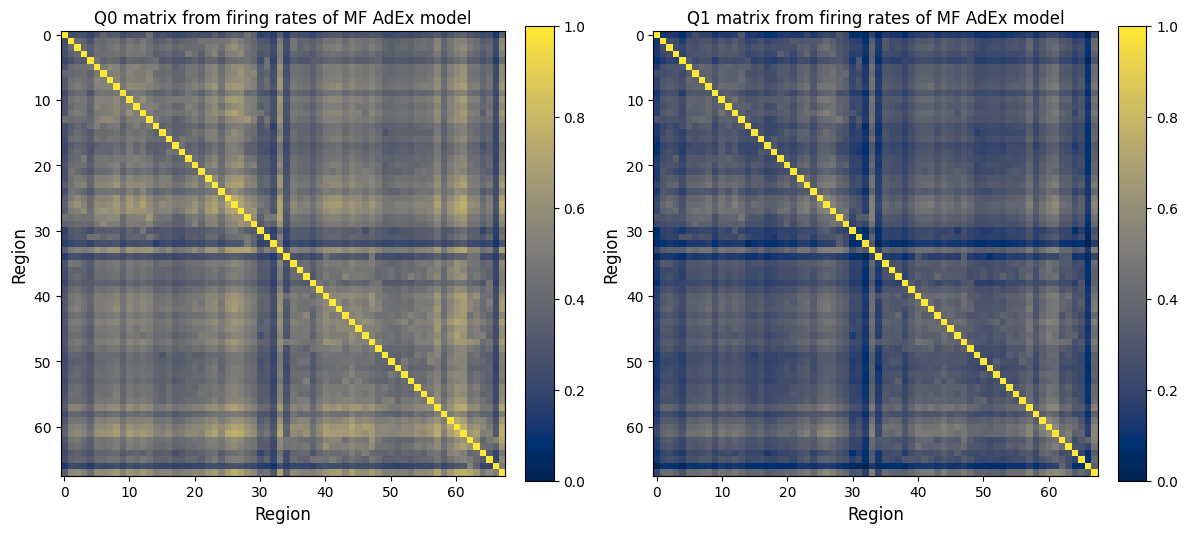

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cmap = plt.cm.cividis
sm = plt.cm.ScalarMappable(cmap=cmap)

axes[0].imshow(Q_data[0], vmin=0, vmax=0.8, cmap='cividis')
axes[0].set_title('Q0 matrix from firing rates of MF AdEx model', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('Region', fontsize=12)

sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0],  pad=0.04, fraction=0.085, shrink=0.8, aspect=16)

axes[1].imshow(Q_data[1], cmap='cividis')
axes[1].set_title('Q1 matrix from firing rates of MF AdEx model', fontsize=12)
axes[1].set_xlabel('Region', fontsize=12)
axes[1].set_ylabel('Region', fontsize=12)

sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], pad=0.04, fraction=0.085, shrink=0.8, aspect=16)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(presentation_figs_dir, f'Q_matrices_MF_AdEx.{graph_format}'), format=graph_format, dpi=300)
plt.close(fig)

#### Verification: Q0 computed with the `lagged_fc_matrices` function gives same result as `np.corrcoef`

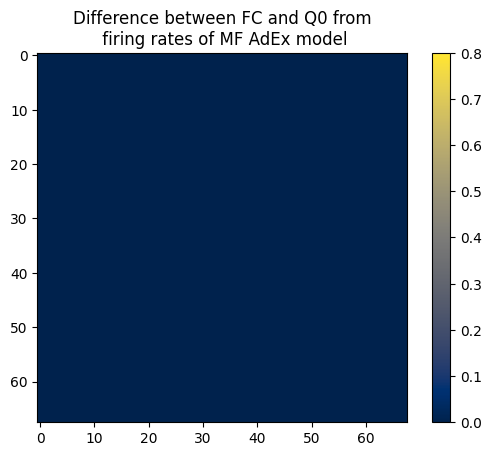

In [35]:
fc_adex_array = np.corrcoef(mf_adex_array.T)
plt.imshow(fc_adex_array - Q_data[0], vmin=0, vmax=0.8, cmap='cividis')
plt.title('Difference between FC and Q0 from\n firing rates of MF AdEx model', fontsize=12)
plt.colorbar()

### Reshape data for running the MOU fitting algorithm

In [36]:
n_sub_test = 1
n_cond_test = 1

# Reshaping Q_data from (n_tau, N, N) to (n_tau, n_sub_test, N, N, n_cond_test) to match input shape for run_MOU_fitting
Q_data = Q_data.reshape(n_tau, n_sub_test, N, N, n_cond_test)
print(Q_data.shape)

(2, 1, 68, 68, 1)


### MOU fitting

  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.006584580542881709


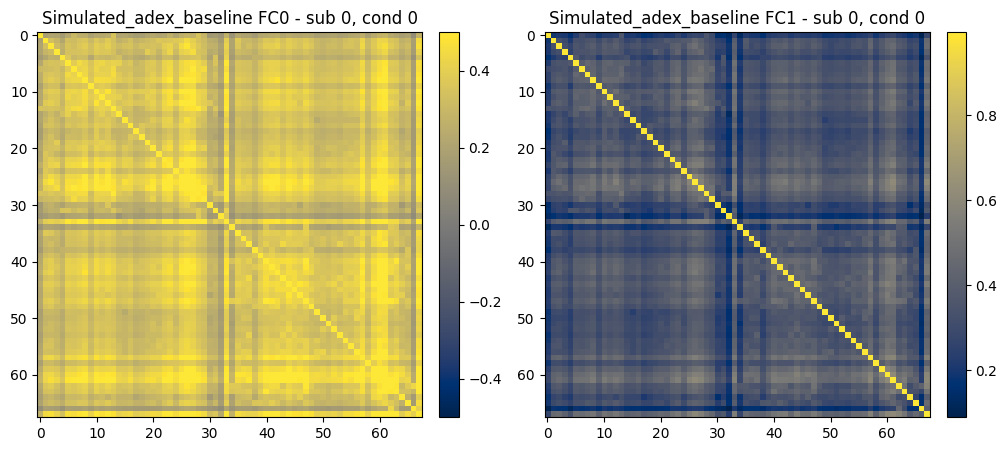

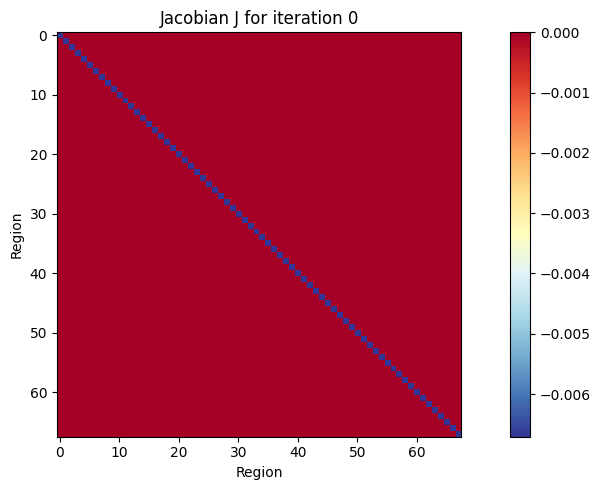

optimisation step: 0 ; model error = 0.9487412483449071
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.006204906392965284


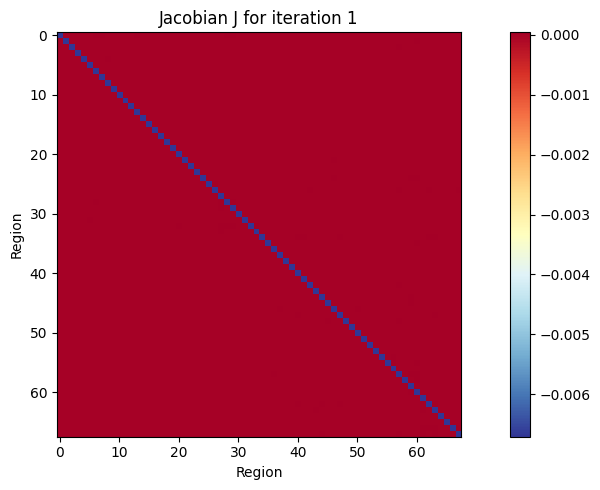

optimisation step: 1 ; model error = 0.9459427782632321
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.005878943684187356


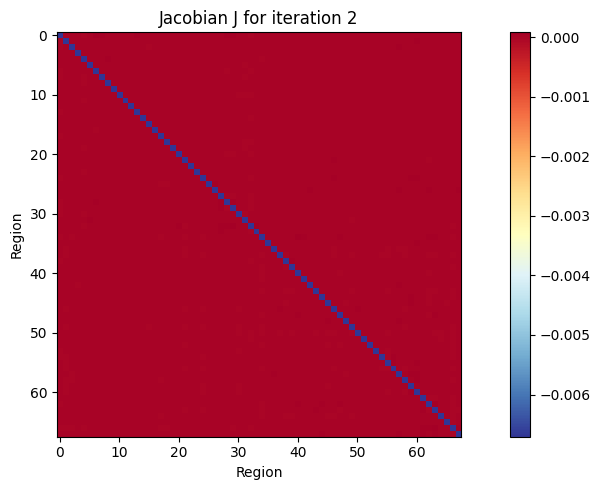

optimisation step: 2 ; model error = 0.9431942571480849
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.005594191896168888


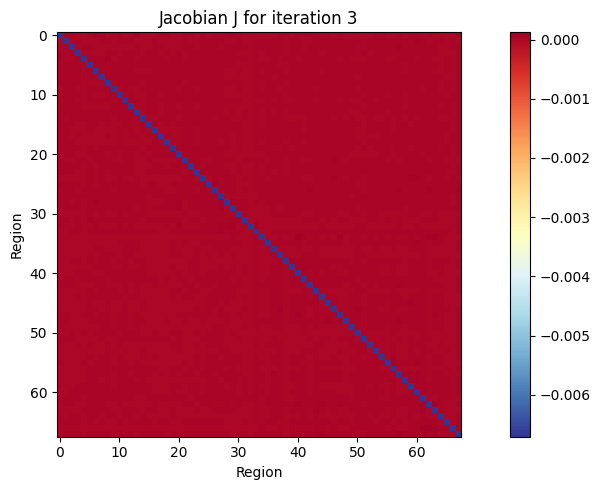

optimisation step: 3 ; model error = 0.940517562722464
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.005342707389416116


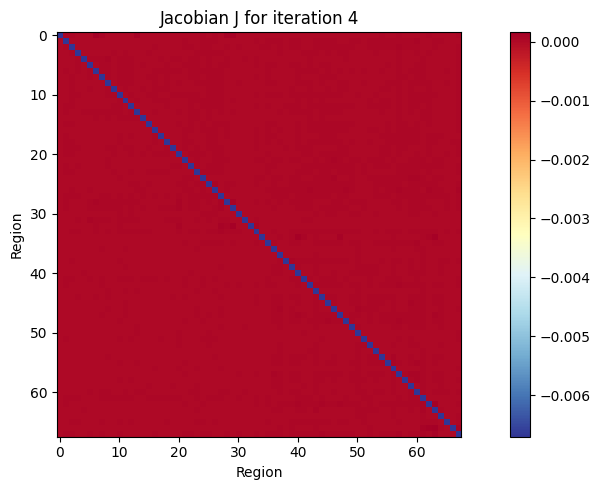

optimisation step: 4 ; model error = 0.937916385919155
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.005119088653252234


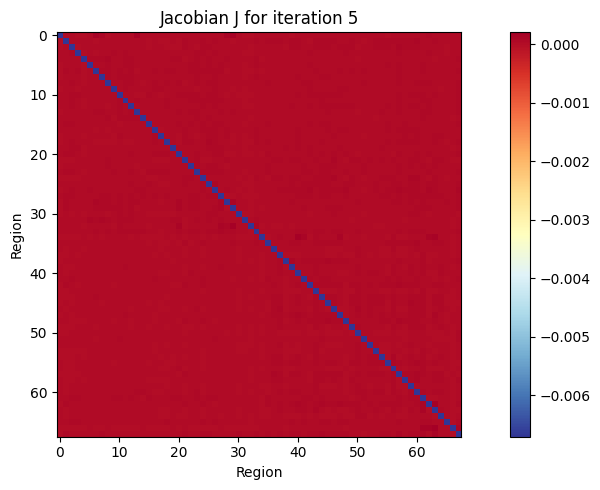

optimisation step: 5 ; model error = 0.93538224589418
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.00491935335227086


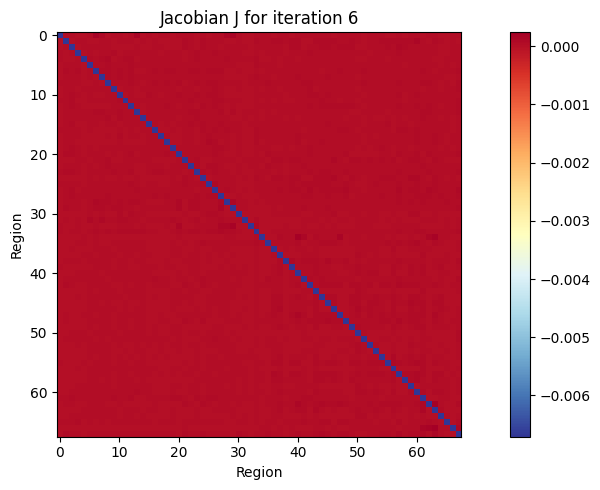

optimisation step: 6 ; model error = 0.9328999497032372
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.004740332321345291


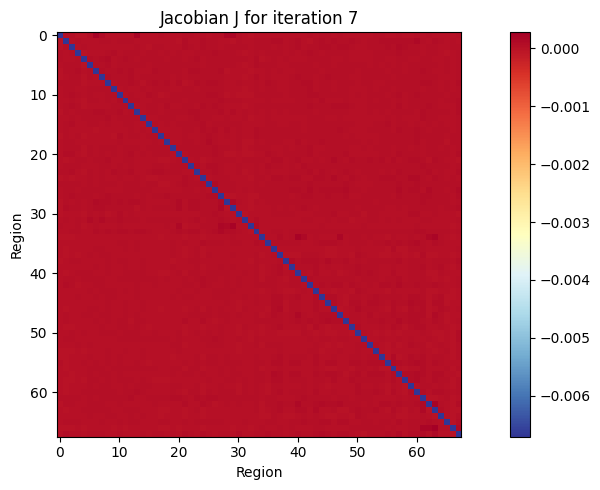

optimisation step: 7 ; model error = 0.9304499023889785
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.004579479360620676


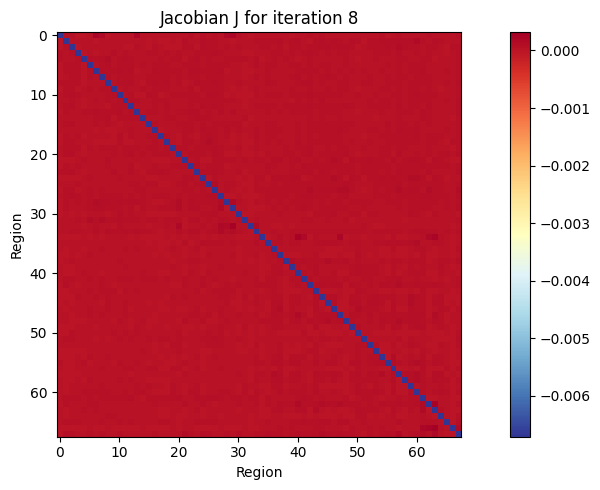

optimisation step: 8 ; model error = 0.9280121152124834
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.004434691992956826


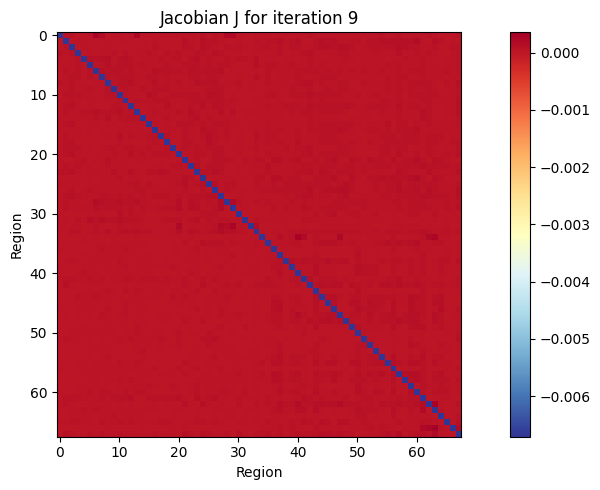

optimisation step: 9 ; model error = 0.9255675298689925
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.004304283363311779


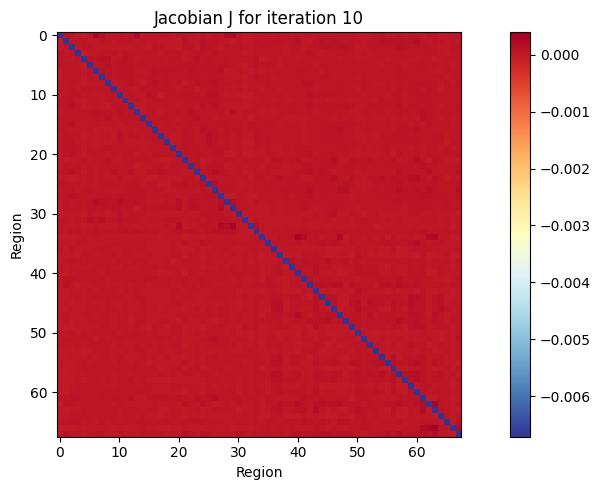

optimisation step: 10 ; model error = 0.9231008665156826
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0041866214551551885


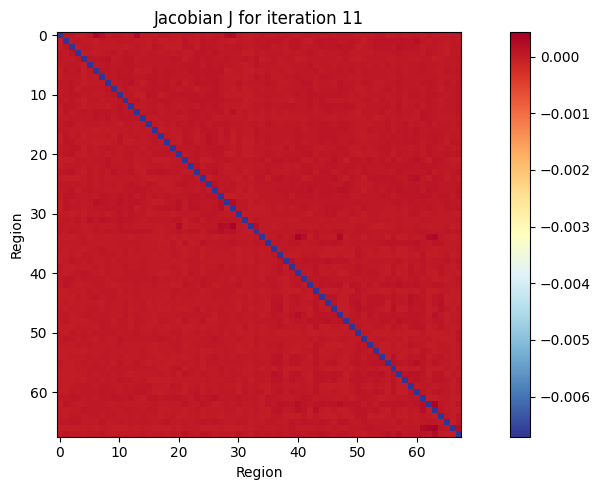

optimisation step: 11 ; model error = 0.9205935377710143
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.004080156781341962


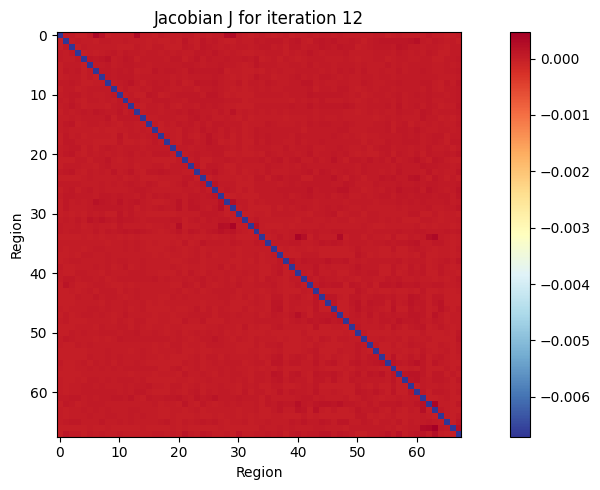

optimisation step: 12 ; model error = 0.9180218297738806
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003983952692997314


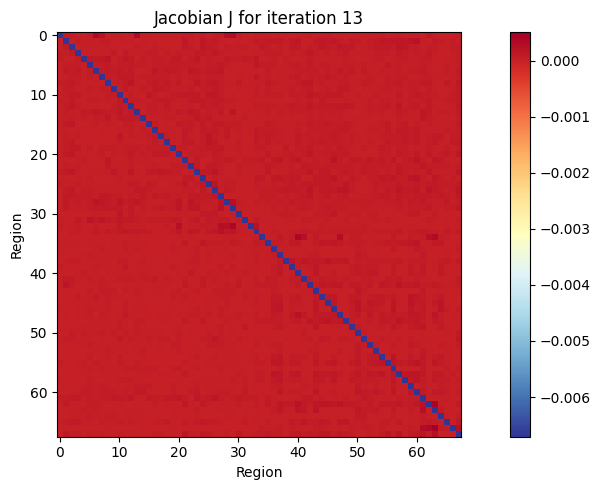

optimisation step: 13 ; model error = 0.9153747098375291
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0038968316284141223


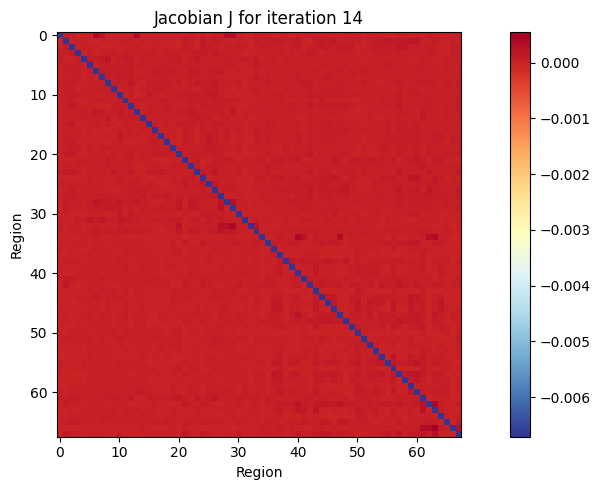

optimisation step: 14 ; model error = 0.9126279351658882
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0038179632693780504


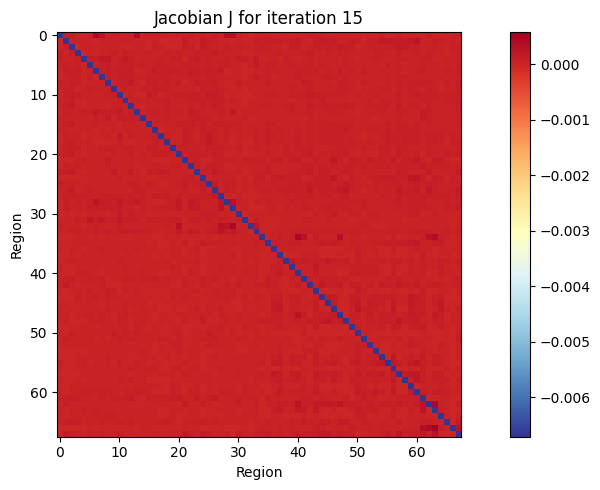

optimisation step: 15 ; model error = 0.9097616682698648
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0037467410636961144


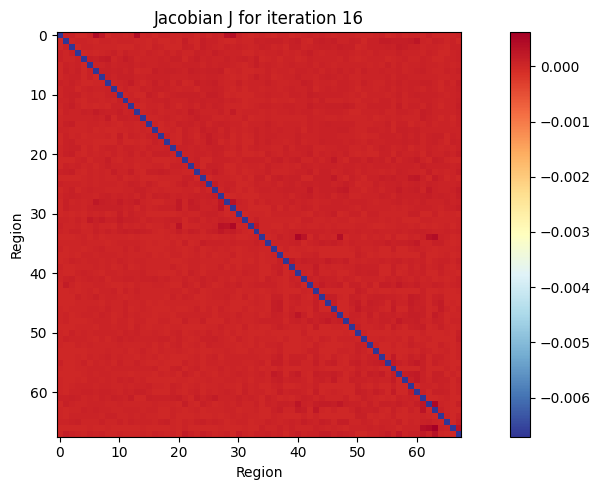

optimisation step: 16 ; model error = 0.9067625503604926
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0036825610437185856


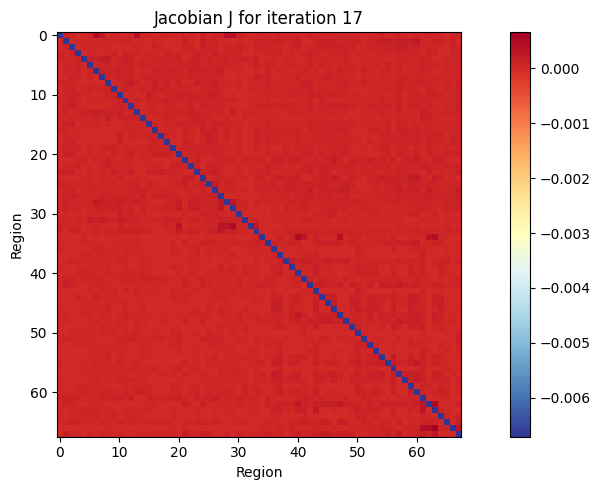

optimisation step: 17 ; model error = 0.9036121537136206
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003624888098856296


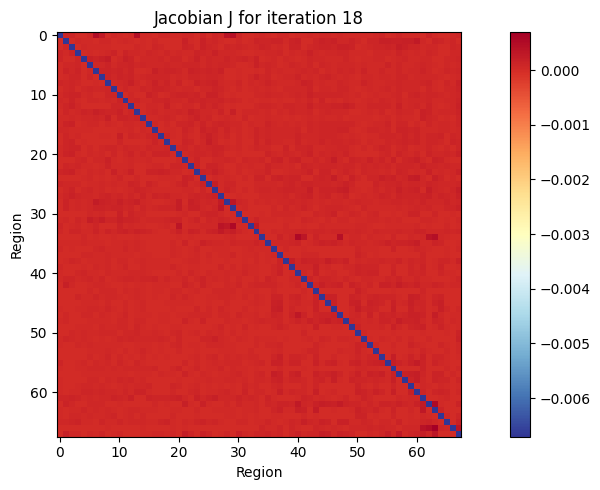

optimisation step: 18 ; model error = 0.9002938856427987
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0035731562159457583


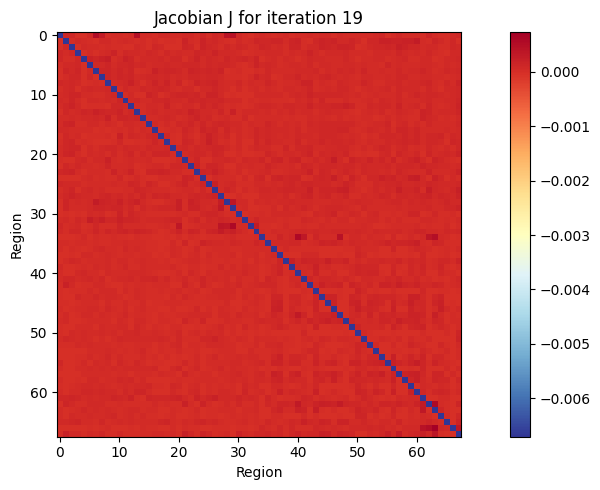

optimisation step: 19 ; model error = 0.8967798149728023
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003526915185193535


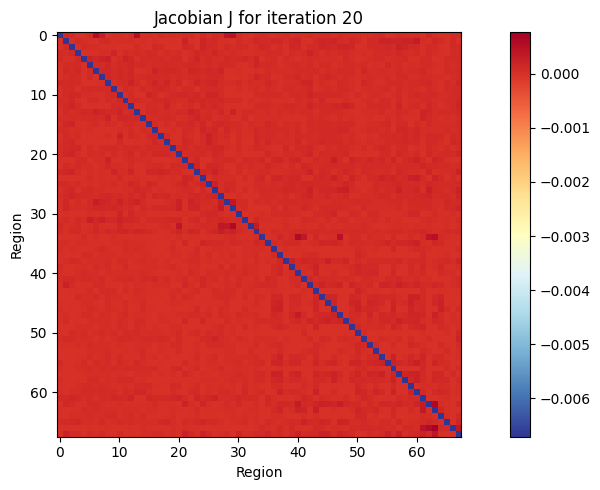

optimisation step: 20 ; model error = 0.8930438352237478
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0034857193908514445


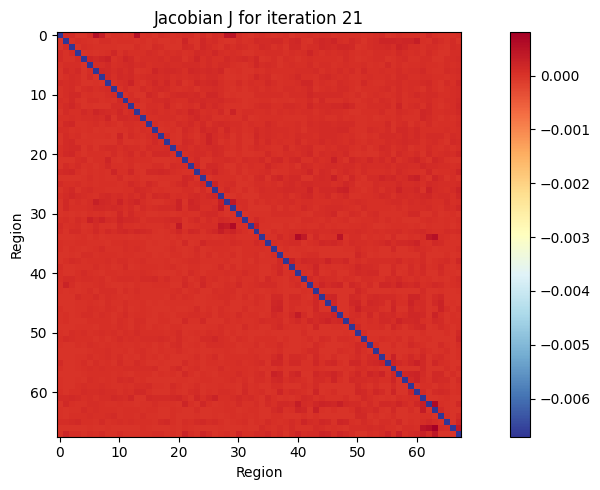

optimisation step: 21 ; model error = 0.8890506608681572
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0034491725026906954


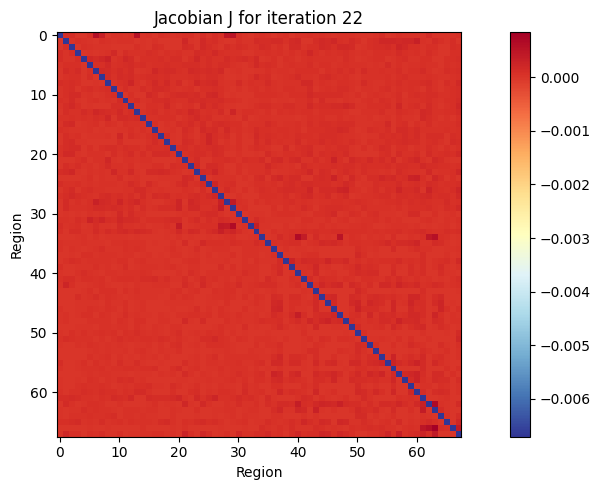

optimisation step: 22 ; model error = 0.8847514299570689
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003417004897969855


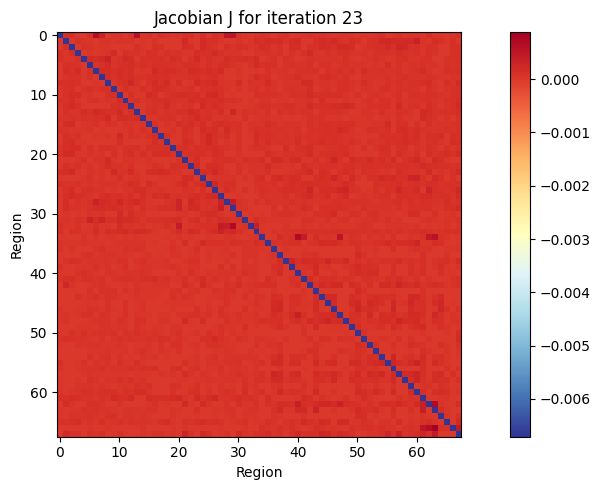

optimisation step: 23 ; model error = 0.8800990579600053
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003388993963720398


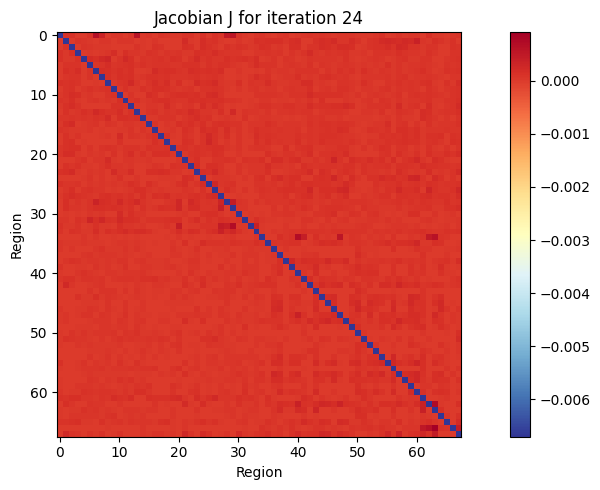

optimisation step: 24 ; model error = 0.8750416880421754
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033649249398614678


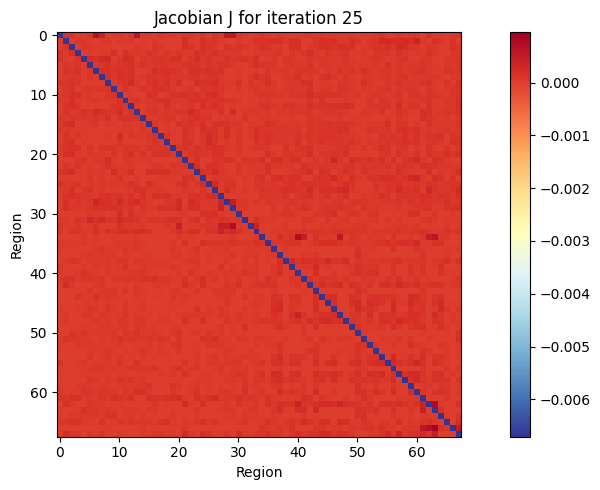

optimisation step: 25 ; model error = 0.8695178847517031
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.00334459877149395


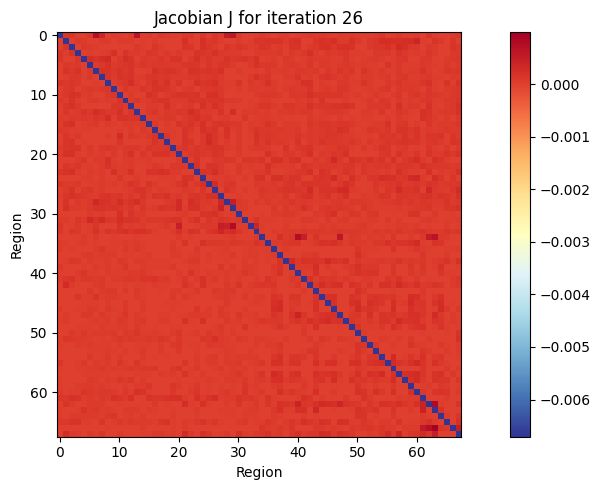

optimisation step: 26 ; model error = 0.8634520401616974
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033278833672903464


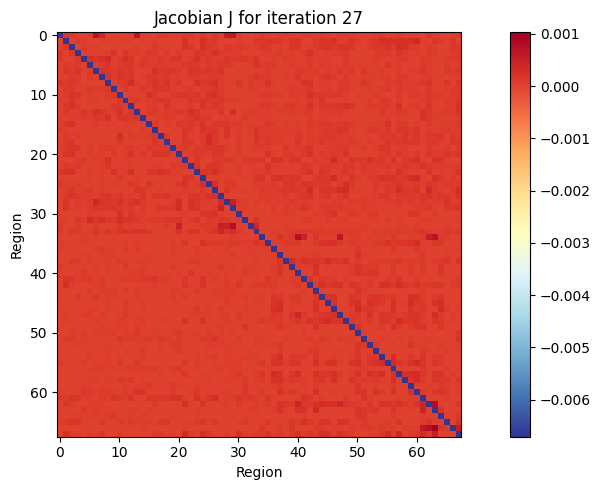

optimisation step: 27 ; model error = 0.8567353010773837
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033146075443974844


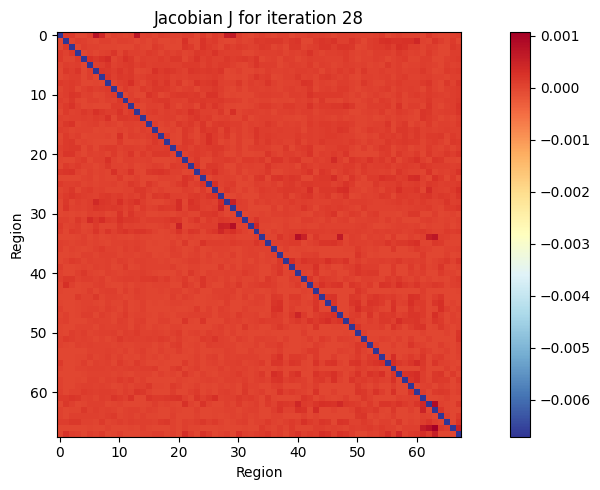

optimisation step: 28 ; model error = 0.8492445031325458
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033045730270008346


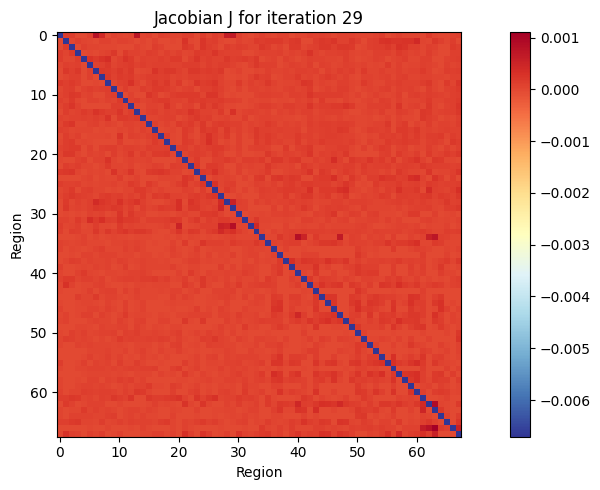

optimisation step: 29 ; model error = 0.8407821601059426
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0032977777295567982


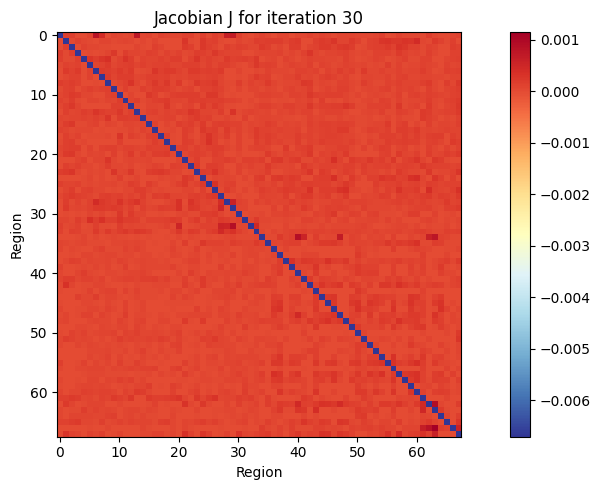

optimisation step: 30 ; model error = 0.8311434435451766
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0032941777873299557


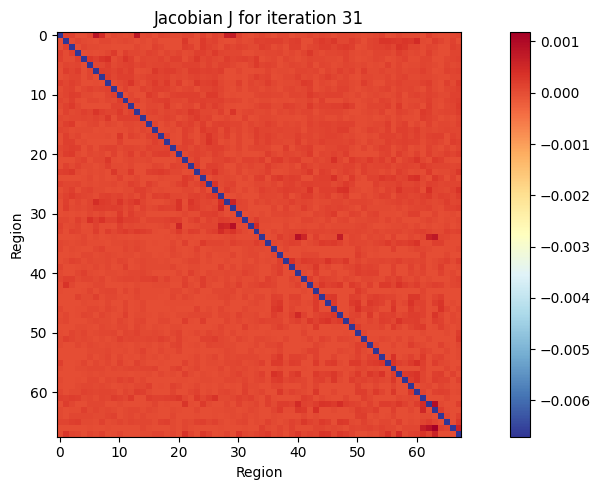

optimisation step: 31 ; model error = 0.8201163178709417
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0032936623195553064


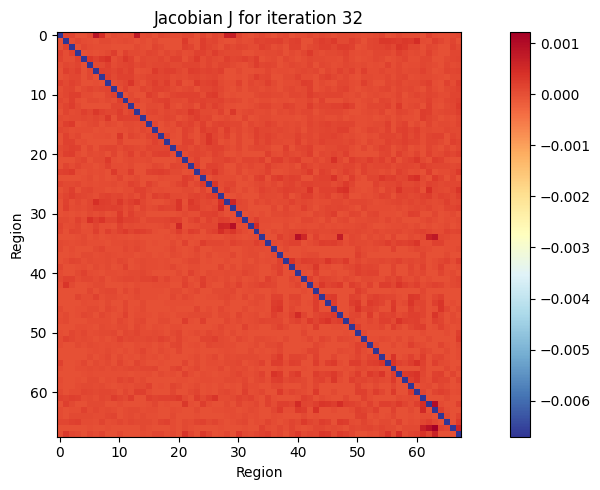

optimisation step: 32 ; model error = 0.8073323101639411
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003296210676446665


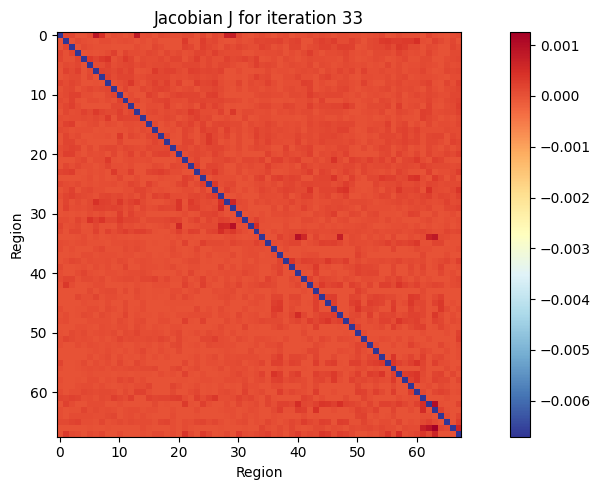

optimisation step: 33 ; model error = 0.792311899421202
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033017923512823335


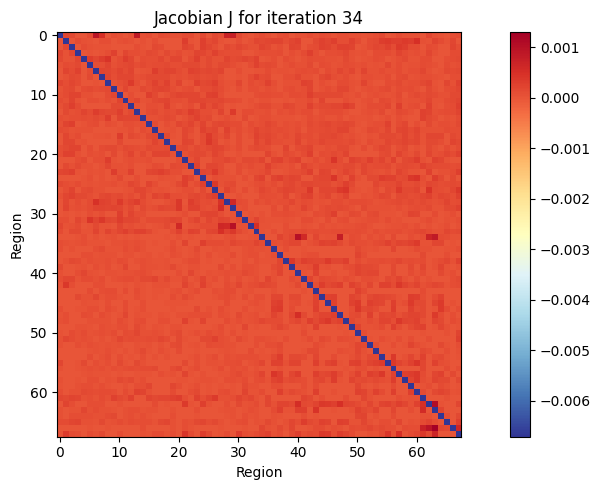

optimisation step: 34 ; model error = 0.7744309865729646
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003310426263300788


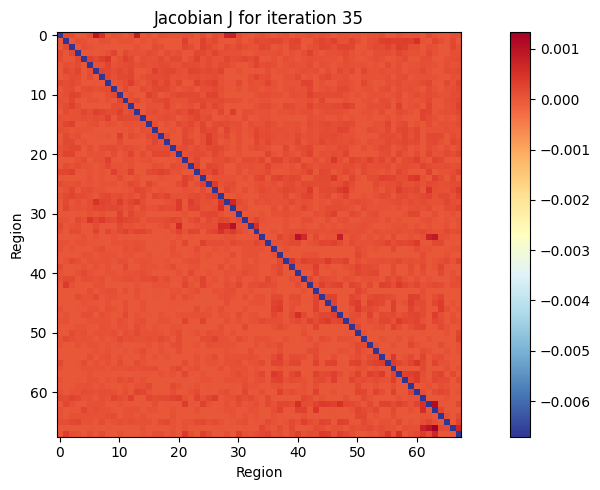

optimisation step: 35 ; model error = 0.752701936236216
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033219949535608635


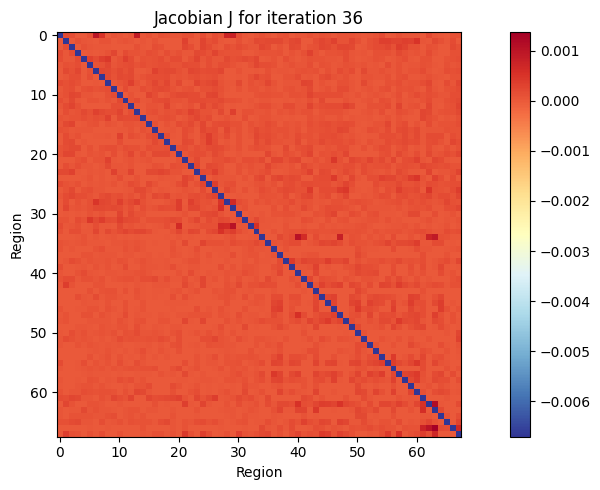

optimisation step: 36 ; model error = 0.7257250994412439
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003336501975964414


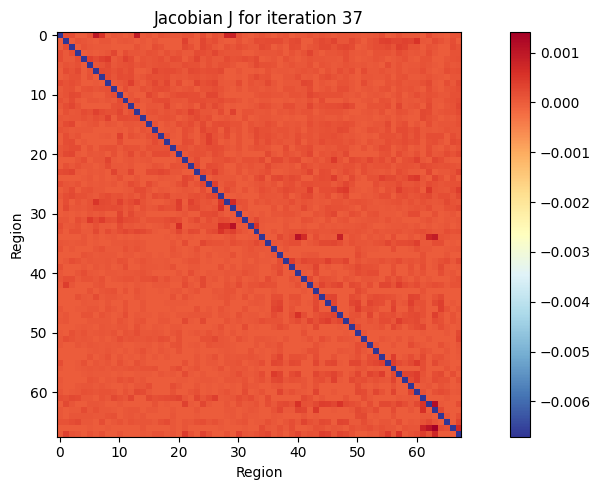

optimisation step: 37 ; model error = 0.6913078622958028
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.003354000259232819


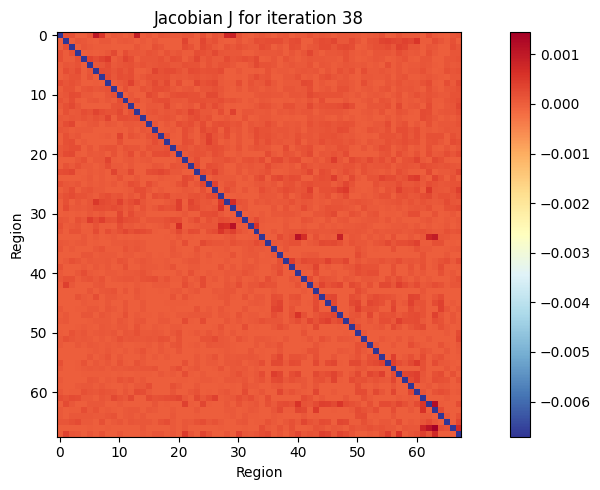

optimisation step: 38 ; model error = 0.6458216875214249
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033745018832704045


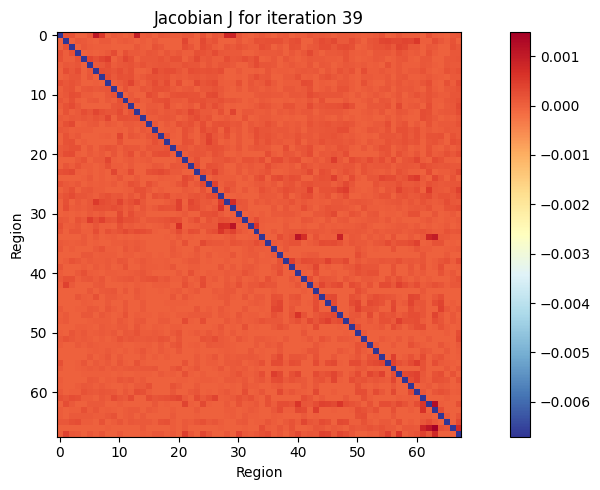

optimisation step: 39 ; model error = 0.5829972399077566
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0033980001156399937


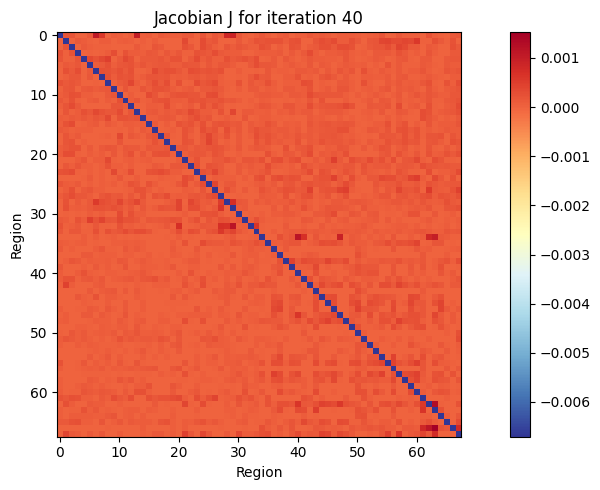

optimisation step: 40 ; model error = 0.4916514292954137
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0034245664377143365


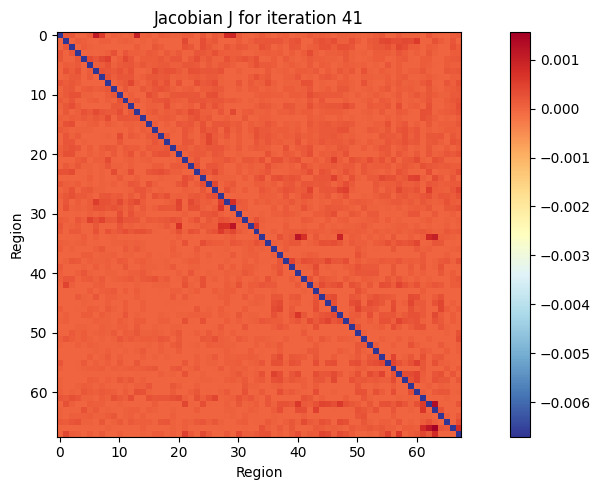

optimisation step: 41 ; model error = 0.3517069272879929
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0034541845047062624


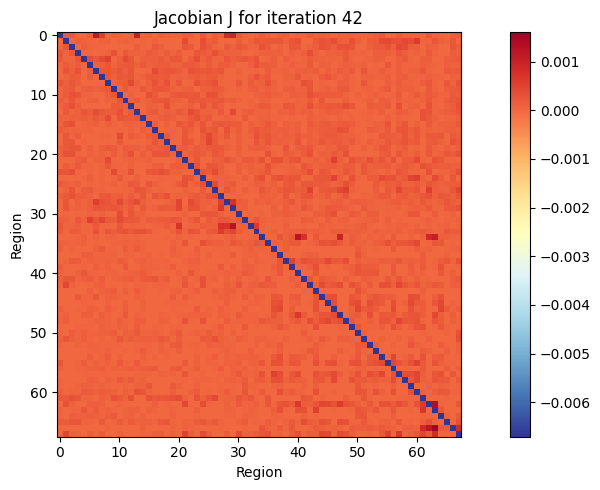

optimisation step: 42 ; model error = 0.23240729757696277
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.0034868736652736106


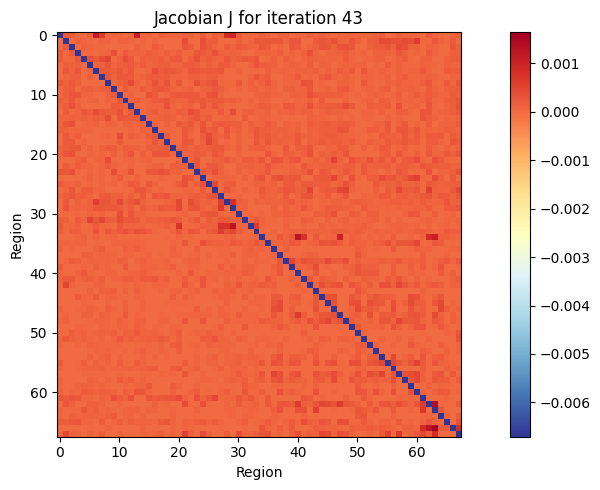

optimisation step: 43 ; model error = 1.0424814813777752
sub 0 ; cond 0 : {'n_tau': 2, 'iterations': 44, 'distance': np.float64(0.23240729757696277), 'correlation': np.float64(0.7481137252416692), 'distance history': array([0.94874125, 0.94594278, 0.94319426, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.66633344, 0.66786613, 0.6693596 , ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(1.0413963153021653), 'distFC1': np.float64(1.0435666474533851), 'eig_iter': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], 'eig_max_real': [np.float64(-0.006708394896689743), np.float64(-0.006267282895876656), np.float64(-0.005881405628636507), np.float64(-0.005537296465276293), np.float64(-0.005226492296396784), np.float64(-0.004943350547486756), np.float64(-0.004683798424995086), np.float64(-0.004444502313377944), np.float64(

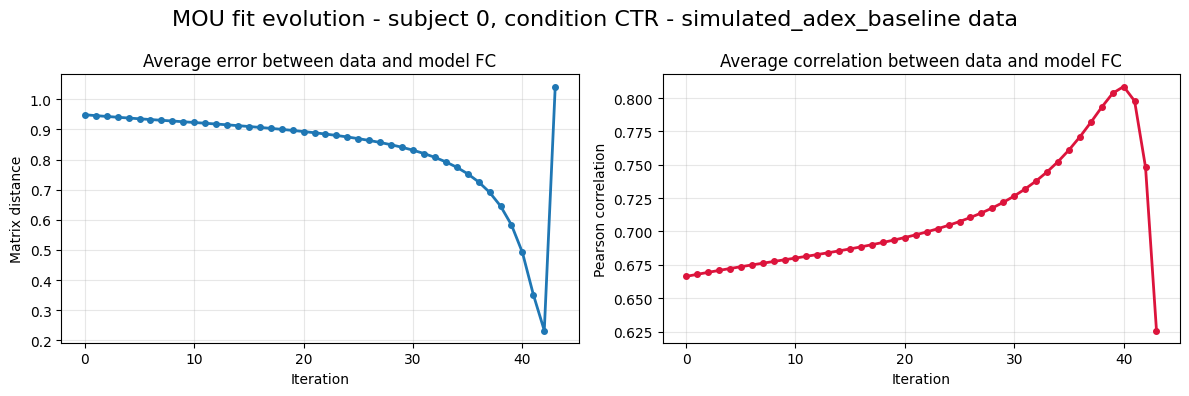

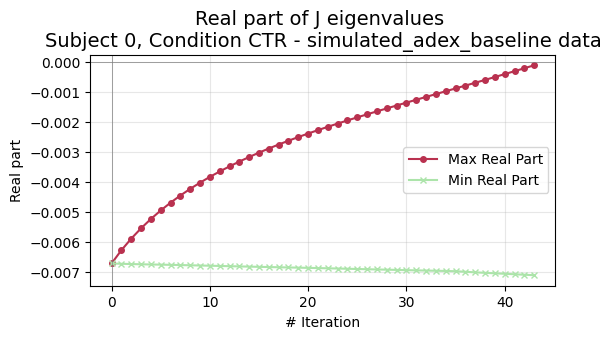

c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:201: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


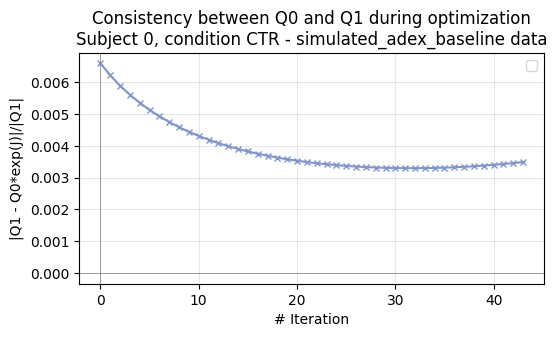

100%|██████████| 1/1 [00:26<00:00, 26.85s/it]

Maximum value of the J matrix: 0.0016
Minimum value of the J matrix: -0.0067
Mean value of the J matrix: -0.0000
Standard deviation of the J matrix: 0.0008
Mean iterations: 44.0
Max iterations: 44
Mean distance FC0: 1.0413963153021653
Mean distance FC1: 1.0435666474533851


In [37]:
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma
min_iter = 10
verbose=True

run_MOU_fitting(n_sub_test, n_cond_test, Q_data, N, situations, situation_idx, mask_Sigma, min_iter,
                    presentation_figs_dir, graph_format, conds, coef_S=None, coef_E=None, verbose=True)

### Loading BOLD signals computed with AdEx MF

In [42]:
situation_idx = 2 # 0 if simulated adex baseline, 1 if simulated adex with reduced gk leak K+ conductance
mf_adex_bold_array = np.load(mf_adex_bold_path, allow_pickle=True)
print(mf_adex_bold_array.shape)
mf_adex_bold_onesub = mf_adex_bold_array[0, :, :]
print(mf_adex_bold_onesub.shape)

(45, 150, 68)
(150, 68)


In [51]:
cut_transient = 5
mf_adex_bold_onesub = mf_adex_bold_onesub[cut_transient:, :]

Text(0.5, 1.0, 'Filtered BOLD activity one subject')

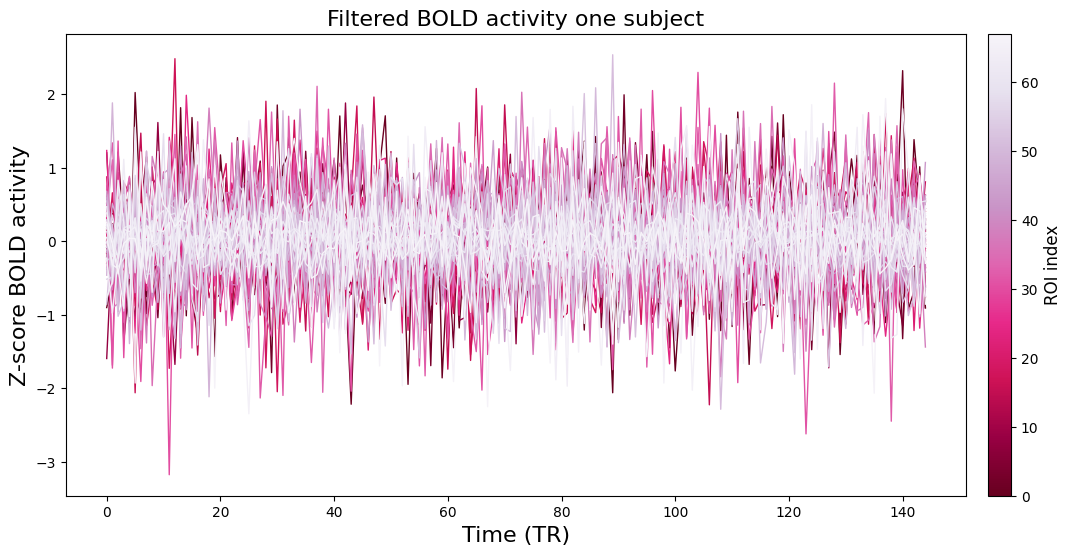

In [52]:
cmap = plt.cm.PuRd_r
n_nodes = N
norm = plt.Normalize(vmin=0, vmax=n_nodes - 1)

fig, ax = plt.subplots(figsize=(14,6))

for roi in range(n_nodes):
	ax.plot(
		range(mf_adex_bold_onesub.shape[0]),
		mf_adex_bold_onesub[ :, roi], color=cmap(norm(roi)), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('ROI index', fontsize=12)

#ax.set_xlim(0, new_array.shape[2] - 1)
ax.set_xlabel('Time (TR)', fontsize=16)
ax.set_ylabel('Z-score BOLD activity', fontsize=16)
ax.set_title(f"Filtered BOLD activity one subject", fontsize = 16)


### Compute Q(0) and Q(1) zero-lag and one-lag covariance matrices from firing rates

In [53]:
Q_data = lagged_fc_matrices(mf_adex_bold_onesub, n_tau=2, diag_zero=False, z_score=True)

### Plot the matrices

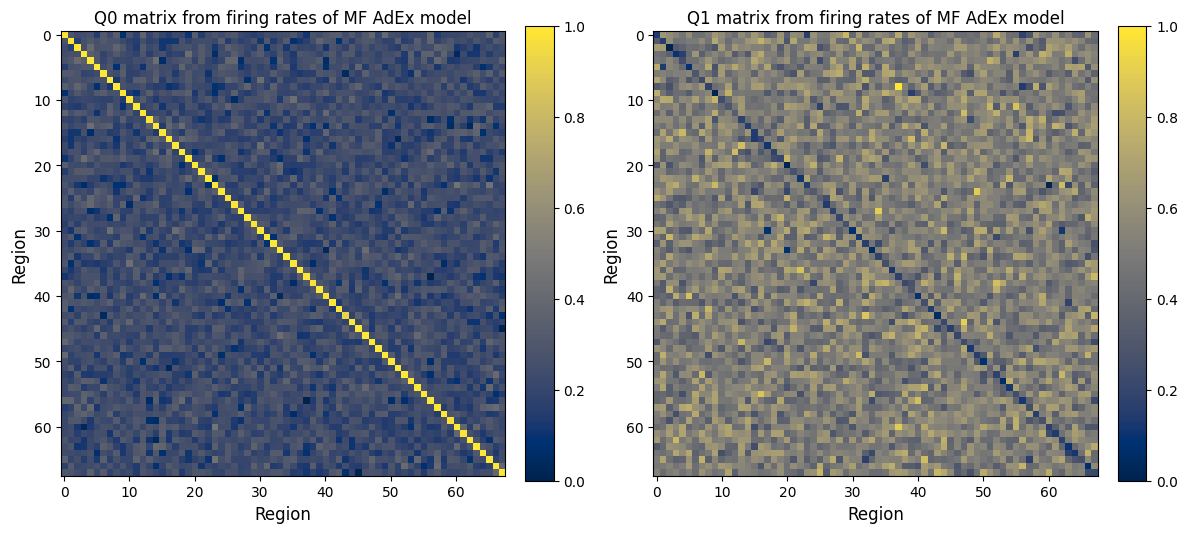

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cmap = plt.cm.cividis
sm = plt.cm.ScalarMappable(cmap=cmap)

axes[0].imshow(Q_data[0], cmap='cividis')
axes[0].set_title('Q0 matrix from firing rates of MF AdEx model', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('Region', fontsize=12)

sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0],  pad=0.04, fraction=0.085, shrink=0.8, aspect=16)

axes[1].imshow(Q_data[1], cmap='cividis')
axes[1].set_title('Q1 matrix from firing rates of MF AdEx model', fontsize=12)
axes[1].set_xlabel('Region', fontsize=12)
axes[1].set_ylabel('Region', fontsize=12)

sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], pad=0.04, fraction=0.085, shrink=0.8, aspect=16)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(presentation_figs_dir, f'Q_matrices_MF_AdEx.{graph_format}'), format=graph_format, dpi=300)
plt.close(fig)

### Reshape data for running the MOU fitting algorithm

In [55]:
n_sub_test = 1
n_cond_test = 1

# Reshaping Q_data from (n_tau, N, N) to (n_tau, n_sub_test, N, N, n_cond_test) to match input shape for run_MOU_fitting
Q_data = Q_data.reshape(n_tau, n_sub_test, N, N, n_cond_test)
print(Q_data.shape)

(2, 1, 68, 68, 1)


### MOU fitting

  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000832616


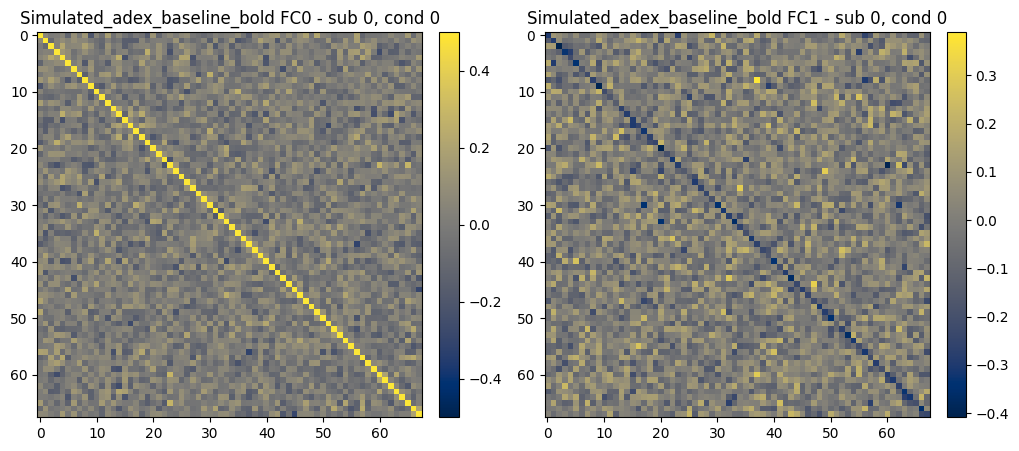

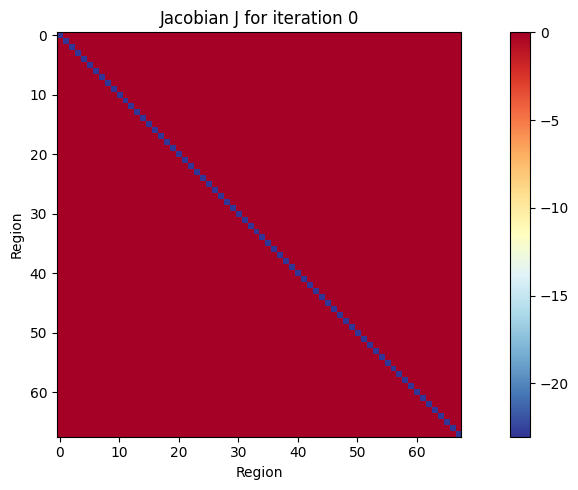

optimisation step: 0 ; model error = 0.7951904003949768
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000013853332


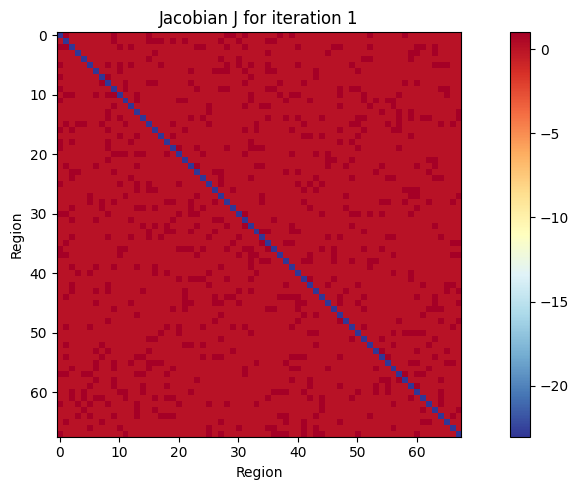

optimisation step: 1 ; model error = 0.8149740959294208
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000001249199


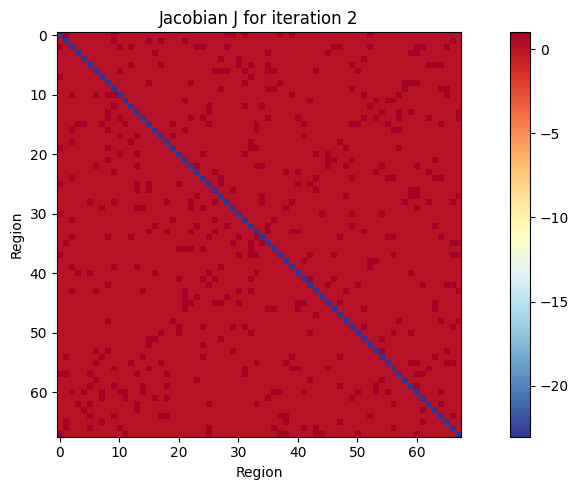

optimisation step: 2 ; model error = 0.8068291209115113
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000913245


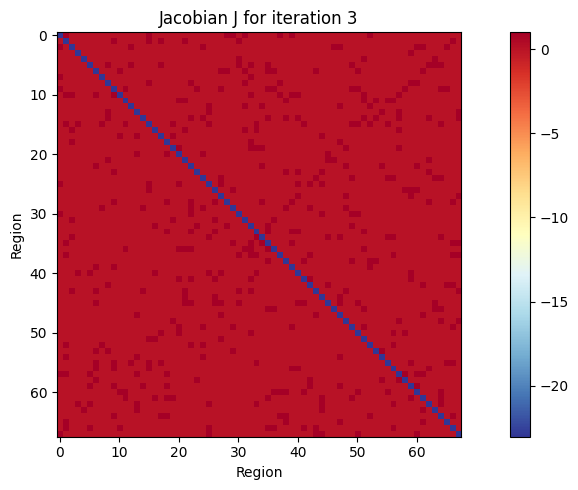

optimisation step: 3 ; model error = 0.806049300291921
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000812557


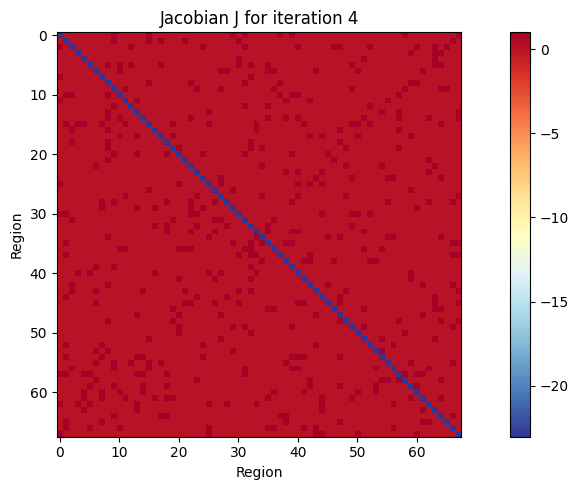

optimisation step: 4 ; model error = 0.806435531542909
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000587819


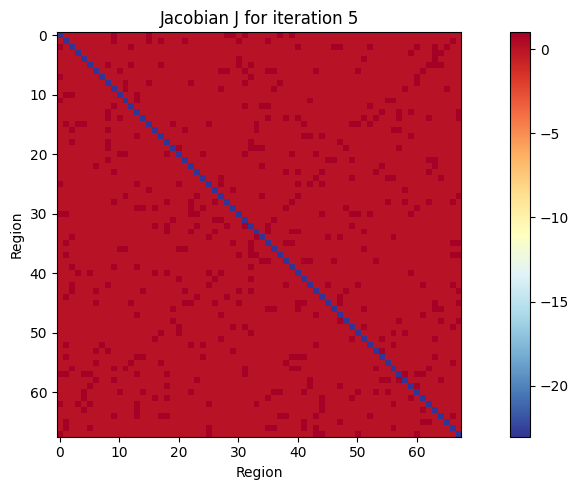

optimisation step: 5 ; model error = 0.8061231865480691
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000472054


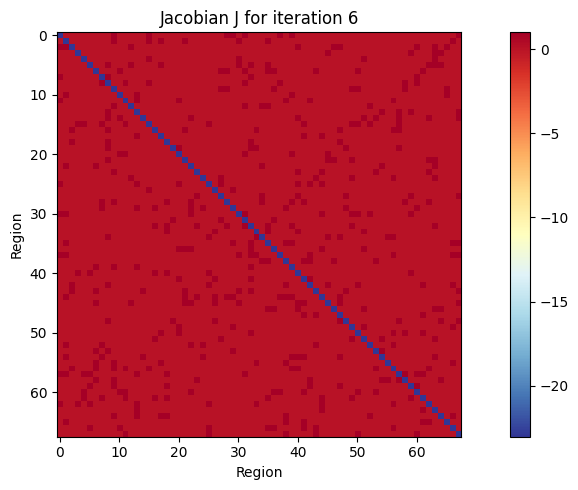

optimisation step: 6 ; model error = 0.8069672139918729
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000020654


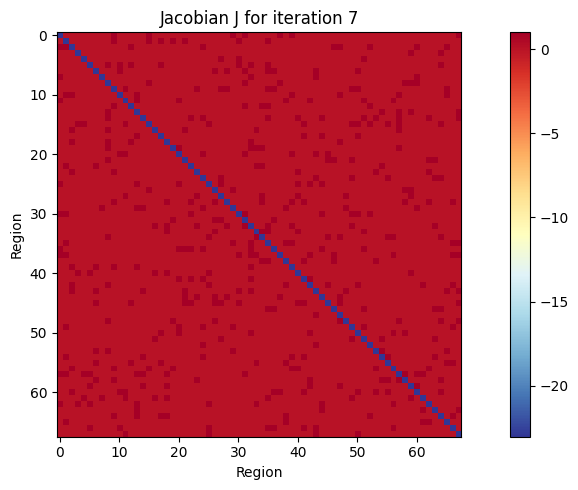

optimisation step: 7 ; model error = 0.8071812807272226
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000037573


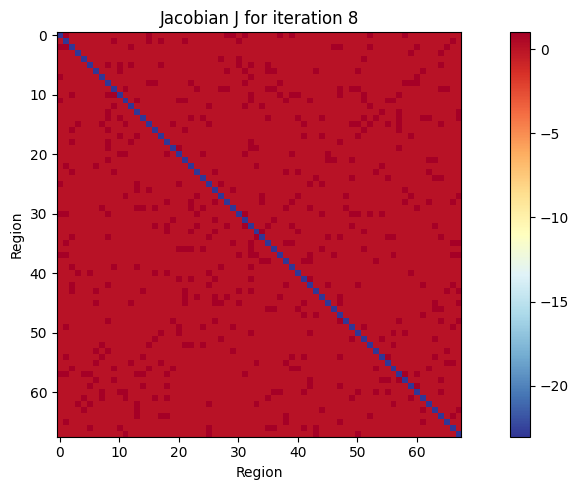

optimisation step: 8 ; model error = 0.8071411788332241
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000591316


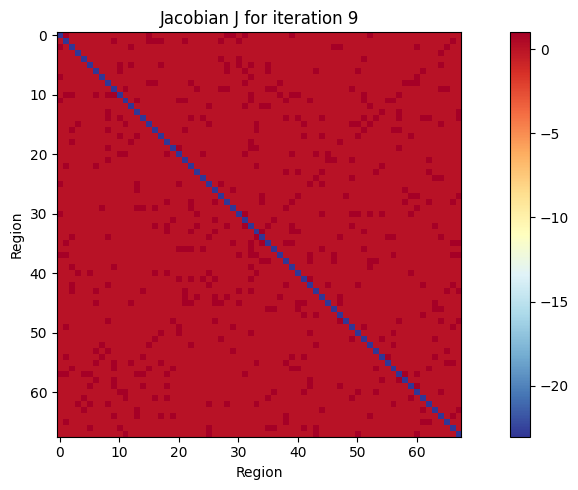

optimisation step: 9 ; model error = 0.8068243528902062
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000033418


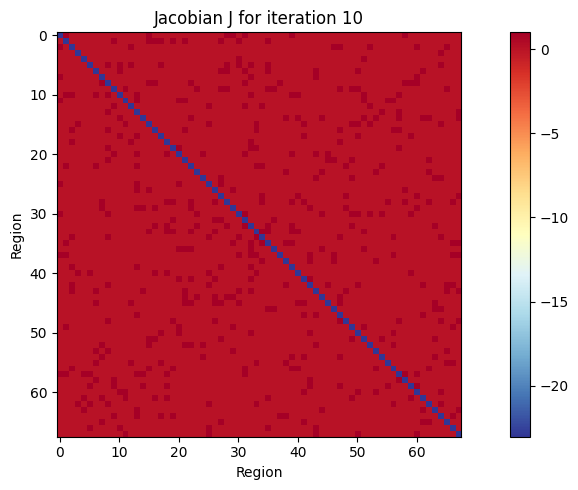

optimisation step: 10 ; model error = 0.8072408251684967
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.9999999999526085


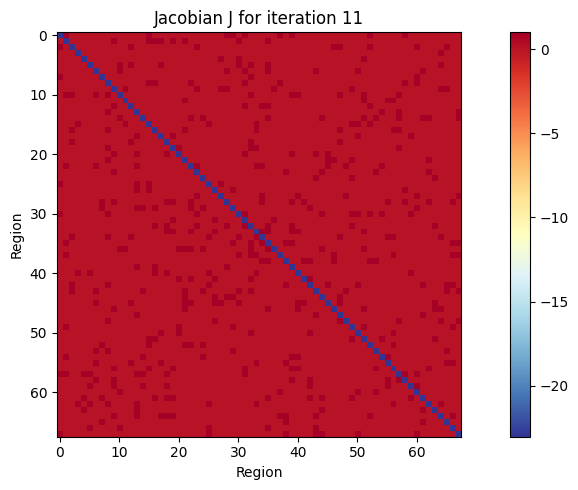

optimisation step: 11 ; model error = 0.8069458444203104
sub 0 ; cond 0 : {'n_tau': 2, 'iterations': 12, 'distance': np.float64(0.7951904003949768), 'correlation': np.float64(0.2346977154960165), 'distance history': array([0.7951904 , 0.8149741 , 0.80682912, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.23469772, 0.42387031, 0.41553067, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.6138916890188111), 'distFC1': np.float64(0.9999999998218095), 'eig_iter': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], 'eig_max_real': [np.float64(-23.032400692543067), np.float64(-13.01155694144434), np.float64(-16.325968092444228), np.float64(-16.68724357971638), np.float64(-16.549534439042702), np.float64(-16.80694499729237), np.float64(-16.535249352542706), np.float64(-16.446082659404578), np.float64(-16.32402054678268), np.float64(-16.517859844936396), np.float64(-16.447399093355227), np.float64(-16.462058864714344)], 'eig_min_real': [np.float64

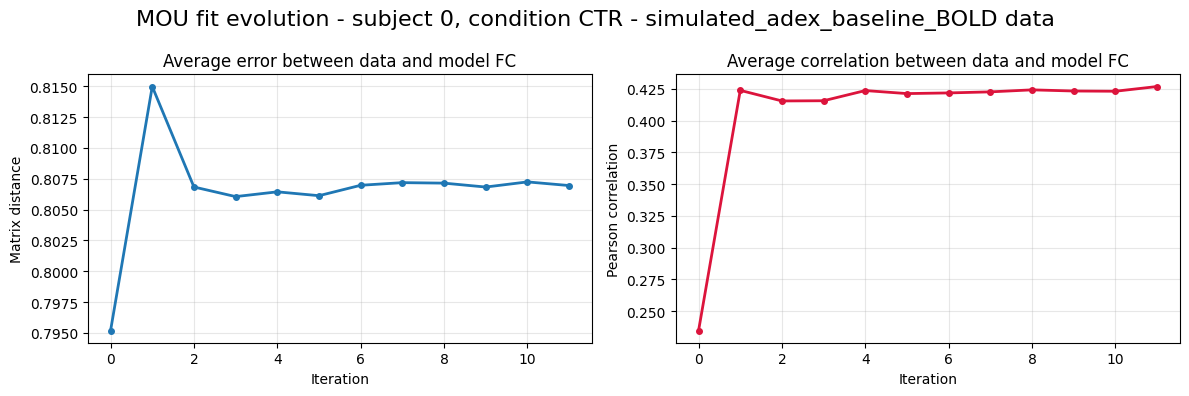

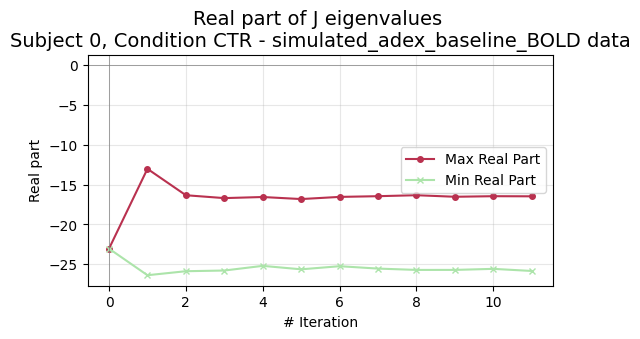

c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:201: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


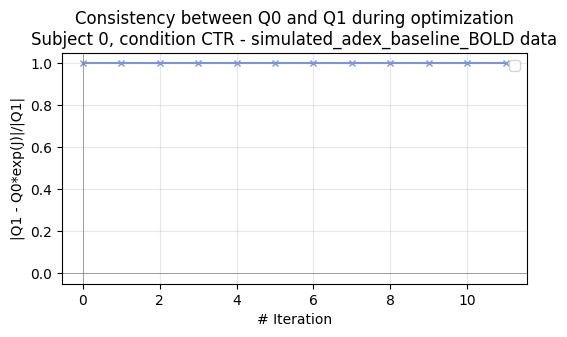

100%|██████████| 1/1 [00:08<00:00,  8.07s/it]

Maximum value of the J matrix: 0.0000
Minimum value of the J matrix: -23.0324
Mean value of the J matrix: -0.3387
Standard deviation of the J matrix: 2.7725
Mean iterations: 12.0
Max iterations: 12
Mean distance FC0: 0.6138916890188111
Mean distance FC1: 0.9999999998218095


In [56]:
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma
min_iter = 10
verbose=True

run_MOU_fitting(n_sub_test, n_cond_test, Q_data, N, situations, situation_idx, mask_Sigma, min_iter,
                    presentation_figs_dir, graph_format, conds, coef_S=None, coef_E=None, verbose=True)